# 1. EDA — Stairs Detection (Open Images V7)
Exploration du dataset Google Open Images V7 — classe Stairs uniquement.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import shutil, random
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("ok")

ok


## 1. Installation et téléchargement

In [2]:
!pip install fiftyone --quiet
print("FiftyOne installé")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.6 MB/s eta 0:00:00

In [3]:
import fiftyone as fo
import fiftyone.zoo as foz

# Télécharger UNIQUEMENT les images annotées "Stairs" depuis Open Images V7
# max_samples=10000 → limite à 10 000 images pour rester dans Kaggle free tier
print("Téléchargement des images Stairs depuis Open Images V7...")
print("Cela peut prendre 10-20 minutes selon la connexion...")

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=["Stairs"],
    max_samples=10000,
    dataset_name="stairs-openimages-train"
)

print(f"\n✅ Dataset téléchargé : {len(dataset)} images")

Téléchargement des images Stairs depuis Open Images V7...
Cela peut prendre 10-20 minutes selon la connexion...
 100% |██████|    4.8Gb/4.8Gb [4.1s elapsed, 0s remaining, 1.2Gb/s]         
Only found 4533 (<10000) samples matching your requirements
 100% |█████████████████| 4533/4533 [4.6m elapsed, 0s remaining, 17.4 files/s]      
Dataset info written to '/root/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'train'
 100% |███████████████| 4533/4533 [28.0s elapsed, 0s remaining, 161.0 samples/s]      
Dataset 'stairs-openimages-train' created

✅ Dataset téléchargé : 4533 images


In [4]:
# Télécharger aussi le split validation
dataset_val = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=["detections"],
    classes=["Stairs"],
    dataset_name="stairs-openimages-val"
)

print(f"✅ Validation : {len(dataset_val)} images")
print(f"✅ Train      : {len(dataset)} images")

 100% |█████████████████████| 36/36 [2.7s elapsed, 0s remaining, 17.5 files/s]      
Dataset info written to '/root/fiftyone/open-images-v7/info.json'
Loading 'open-images-v7' split 'validation'
 100% |███████████████████| 36/36 [265.1ms elapsed, 0s remaining, 137.5 samples/s]    
Dataset 'stairs-openimages-val' created
✅ Validation : 36 images
✅ Train      : 4533 images


## 2. Statistiques générales

In [5]:
# Compter les annotations
total_boxes = 0
img_with_stairs = 0

for sample in dataset:
    detections = sample.ground_truth.detections if sample.ground_truth else []
    stairs_boxes = [d for d in detections if d.label == "Stairs"]
    if stairs_boxes:
        img_with_stairs += 1
        total_boxes += len(stairs_boxes)

print("=" * 45)
print(f"  Images train totales     : {len(dataset)}")
print(f"  Images avec Stairs       : {img_with_stairs}")
print(f"  Total bounding boxes     : {total_boxes}")
print(f"  Moyenne bbox par image   : {total_boxes/max(img_with_stairs,1):.2f}")
print(f"  Images val               : {len(dataset_val)}")
print("=" * 45)

  Images train totales     : 4533
  Images avec Stairs       : 4533
  Total bounding boxes     : 5981
  Moyenne bbox par image   : 1.32
  Images val               : 36


## 3. Distribution des bounding boxes

In [6]:
# Collecter les dimensions des bounding boxes
bbox_widths  = []
bbox_heights = []
bbox_areas   = []
boxes_per_image = []

for sample in dataset:
    detections = sample.ground_truth.detections if sample.ground_truth else []
    stairs_boxes = [d for d in detections if d.label == "Stairs"]
    boxes_per_image.append(len(stairs_boxes))

    for d in stairs_boxes:
        # bbox = [x, y, width, height] normalisé 0-1
        w = d.bounding_box[2]
        h = d.bounding_box[3]
        bbox_widths.append(w)
        bbox_heights.append(h)
        bbox_areas.append(w * h)

bbox_widths  = np.array(bbox_widths)
bbox_heights = np.array(bbox_heights)
bbox_areas   = np.array(bbox_areas)

print("Statistiques bounding boxes (normalisées 0-1) :")
print(f"  Largeur  — min: {bbox_widths.min():.3f} | max: {bbox_widths.max():.3f} | moy: {bbox_widths.mean():.3f}")
print(f"  Hauteur  — min: {bbox_heights.min():.3f} | max: {bbox_heights.max():.3f} | moy: {bbox_heights.mean():.3f}")
print(f"  Aire     — min: {bbox_areas.min():.4f} | max: {bbox_areas.max():.4f} | moy: {bbox_areas.mean():.4f}")
print(f"\nNombre de bbox par image :")
print(f"  Min: {min(boxes_per_image)} | Max: {max(boxes_per_image)} | Moy: {np.mean(boxes_per_image):.2f}")

Statistiques bounding boxes (normalisées 0-1) :
  Largeur  — min: 0.016 | max: 1.000 | moy: 0.477
  Hauteur  — min: 0.018 | max: 0.999 | moy: 0.423
  Aire     — min: 0.0005 | max: 0.9988 | moy: 0.2482

Nombre de bbox par image :
  Min: 1 | Max: 13 | Moy: 1.32


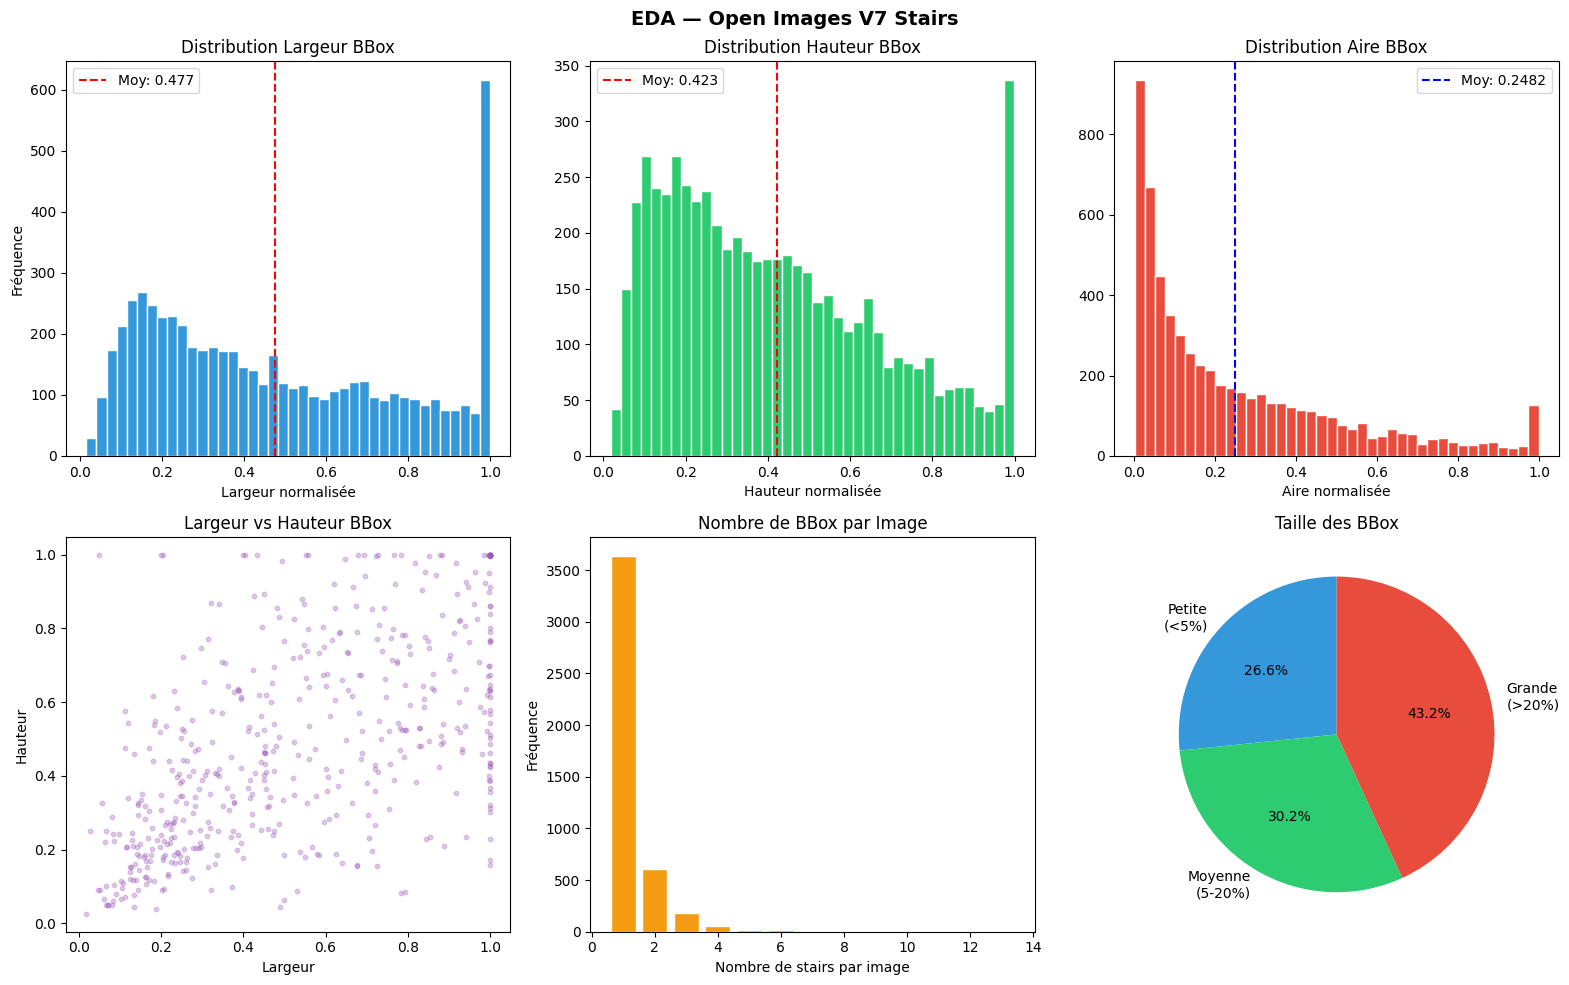


Répartition par taille :
  Petite  (<5%  aire) : 1593  (26.6%)
  Moyenne (5-20%)     : 1806 (30.2%)
  Grande  (>20%)      : 2582  (43.2%)


In [7]:
# Visualisation distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Distribution largeur bbox
axes[0,0].hist(bbox_widths, bins=40, color='#3498db', edgecolor='white')
axes[0,0].set_title('Distribution Largeur BBox')
axes[0,0].set_xlabel('Largeur normalisée')
axes[0,0].set_ylabel('Fréquence')
axes[0,0].axvline(bbox_widths.mean(), color='red', ls='--', label=f'Moy: {bbox_widths.mean():.3f}')
axes[0,0].legend()

# 2. Distribution hauteur bbox
axes[0,1].hist(bbox_heights, bins=40, color='#2ecc71', edgecolor='white')
axes[0,1].set_title('Distribution Hauteur BBox')
axes[0,1].set_xlabel('Hauteur normalisée')
axes[0,1].axvline(bbox_heights.mean(), color='red', ls='--', label=f'Moy: {bbox_heights.mean():.3f}')
axes[0,1].legend()

# 3. Distribution aire bbox
axes[0,2].hist(bbox_areas, bins=40, color='#e74c3c', edgecolor='white')
axes[0,2].set_title('Distribution Aire BBox')
axes[0,2].set_xlabel('Aire normalisée')
axes[0,2].axvline(bbox_areas.mean(), color='blue', ls='--', label=f'Moy: {bbox_areas.mean():.4f}')
axes[0,2].legend()

# 4. Scatter largeur vs hauteur
axes[1,0].scatter(bbox_widths[:500], bbox_heights[:500], alpha=0.3, color='#9b59b6', s=10)
axes[1,0].set_title('Largeur vs Hauteur BBox')
axes[1,0].set_xlabel('Largeur')
axes[1,0].set_ylabel('Hauteur')

# 5. Distribution nombre bbox par image
counter = Counter(boxes_per_image)
axes[1,1].bar(counter.keys(), counter.values(), color='#f39c12', edgecolor='white')
axes[1,1].set_title('Nombre de BBox par Image')
axes[1,1].set_xlabel('Nombre de stairs par image')
axes[1,1].set_ylabel('Fréquence')

# 6. Taille des bbox — petite/moyenne/grande
small  = (bbox_areas < 0.05).sum()
medium = ((bbox_areas >= 0.05) & (bbox_areas < 0.20)).sum()
large  = (bbox_areas >= 0.20).sum()
axes[1,2].pie([small, medium, large],
              labels=[f'Petite\n(<5%)', f'Moyenne\n(5-20%)', f'Grande\n(>20%)'],
              colors=['#3498db', '#2ecc71', '#e74c3c'],
              autopct='%1.1f%%', startangle=90)
axes[1,2].set_title('Taille des BBox')

plt.suptitle('EDA — Open Images V7 Stairs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRépartition par taille :")
print(f"  Petite  (<5%  aire) : {small}  ({small/len(bbox_areas)*100:.1f}%)")
print(f"  Moyenne (5-20%)     : {medium} ({medium/len(bbox_areas)*100:.1f}%)")
print(f"  Grande  (>20%)      : {large}  ({large/len(bbox_areas)*100:.1f}%)")

## 4. Visualisation des images avec annotations

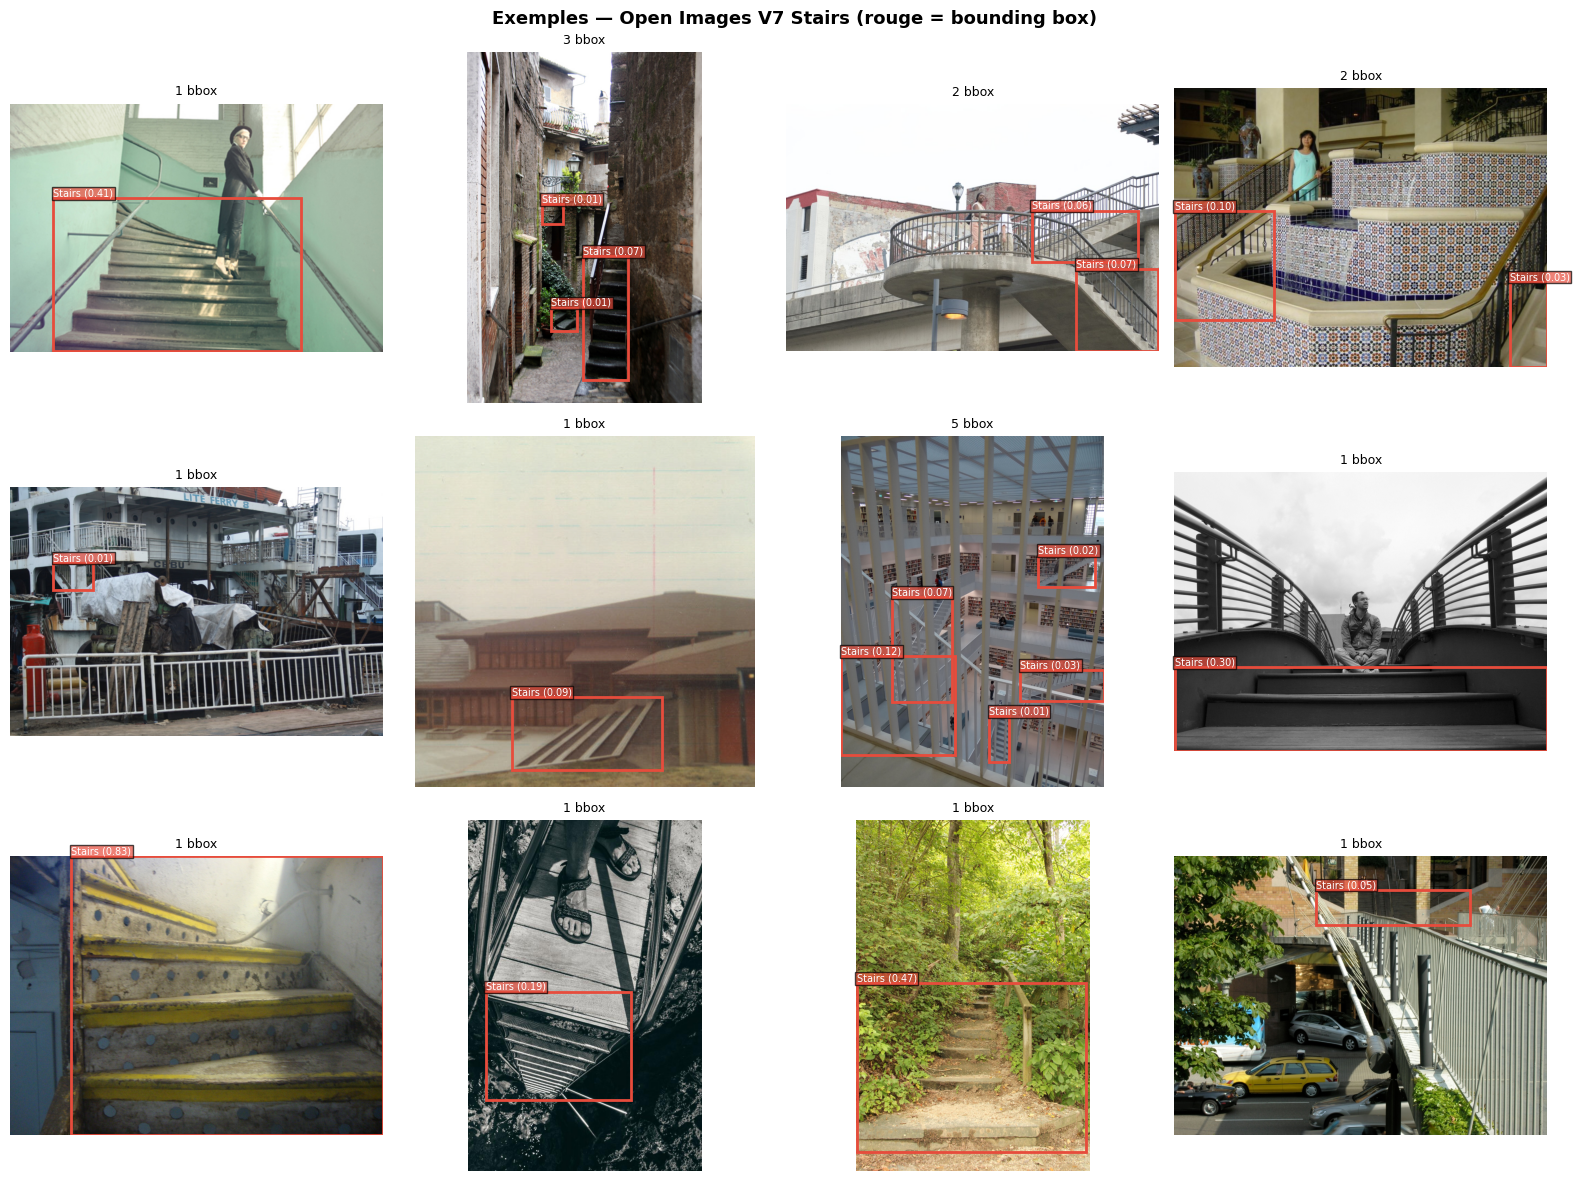

In [8]:
# Afficher 12 exemples d'images avec bounding boxes
import random
random.seed(42)

samples_list = list(dataset.take(50))
samples_show = random.sample(samples_list, min(12, len(samples_list)))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, sample in enumerate(samples_show):
    ax = axes.flat[i]

    try:
        img = Image.open(sample.filepath).convert("RGB")
        w_img, h_img = img.size
        ax.imshow(img)

        detections = sample.ground_truth.detections if sample.ground_truth else []
        stairs_boxes = [d for d in detections if d.label == "Stairs"]

        for d in stairs_boxes:
            x, y, bw, bh = d.bounding_box
            rect = patches.Rectangle(
                (x * w_img, y * h_img),
                bw * w_img, bh * h_img,
                linewidth=2, edgecolor='#e74c3c', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x * w_img, y * h_img - 5,
                    f'Stairs ({bw*bh:.2f})',
                    color='white', fontsize=7,
                    bbox=dict(facecolor='#e74c3c', alpha=0.7, pad=1))

        ax.set_title(f'{len(stairs_boxes)} bbox', fontsize=9)
        ax.axis('off')

    except Exception as e:
        ax.axis('off')
        ax.set_title('Erreur', fontsize=9)

plt.suptitle('Exemples — Open Images V7 Stairs (rouge = bounding box)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Analyse de la qualité des annotations

In [9]:
# Détecter les annotations potentiellement problématiques
tres_petites = []  # bbox trop petite → difficile à détecter
tres_grandes = []  # bbox presque toute l'image → peut être imprécise
multiples    = []  # images avec beaucoup de bbox

for sample in dataset:
    detections = sample.ground_truth.detections if sample.ground_truth else []
    stairs_boxes = [d for d in detections if d.label == "Stairs"]

    for d in stairs_boxes:
        aire = d.bounding_box[2] * d.bounding_box[3]
        if aire < 0.01:
            tres_petites.append(sample.filepath)
        if aire > 0.80:
            tres_grandes.append(sample.filepath)

    if len(stairs_boxes) > 5:
        multiples.append((sample.filepath, len(stairs_boxes)))

print("Analyse qualité annotations :")
print(f"  BBox très petites (<1% aire)  : {len(tres_petites)} ({len(tres_petites)/total_boxes*100:.1f}%)")
print(f"  BBox très grandes (>80% aire) : {len(tres_grandes)} ({len(tres_grandes)/total_boxes*100:.1f}%)")
print(f"  Images avec >5 stairs         : {len(multiples)}")
if multiples:
    print(f"  Exemples : {multiples[:3]}")

Analyse qualité annotations :
  BBox très petites (<1% aire)  : 338 (5.7%)
  BBox très grandes (>80% aire) : 318 (5.3%)
  Images avec >5 stairs         : 35
  Exemples : [('/root/fiftyone/open-images-v7/train/data/0473c829e5576d94.jpg', 6), ('/root/fiftyone/open-images-v7/train/data/0cecb524e830836d.jpg', 7), ('/root/fiftyone/open-images-v7/train/data/0d85a8a1df22ed8c.jpg', 6)]


## 6. Conversion et sauvegarde CSV

In [10]:
# Convertir en DataFrame pour le preprocessing
rows = []

for sample in dataset:
    detections = sample.ground_truth.detections if sample.ground_truth else []
    stairs_boxes = [d for d in detections if d.label == "Stairs"]

    if stairs_boxes:
        for d in stairs_boxes:
            x, y, bw, bh = d.bounding_box
            rows.append({
                "filepath": sample.filepath,
                "label":    "stairs",
                "x_norm":   round(x, 6),
                "y_norm":   round(y, 6),
                "w_norm":   round(bw, 6),
                "h_norm":   round(bh, 6),
                "area":     round(bw * bh, 6),
                "split":    "train"
            })

for sample in dataset_val:
    detections = sample.ground_truth.detections if sample.ground_truth else []
    stairs_boxes = [d for d in detections if d.label == "Stairs"]

    if stairs_boxes:
        for d in stairs_boxes:
            x, y, bw, bh = d.bounding_box
            rows.append({
                "filepath": sample.filepath,
                "label":    "stairs",
                "x_norm":   round(x, 6),
                "y_norm":   round(y, 6),
                "w_norm":   round(bw, 6),
                "h_norm":   round(bh, 6),
                "area":     round(bw * bh, 6),
                "split":    "val"
            })

df = pd.DataFrame(rows)

print(f"DataFrame créé : {len(df)} annotations")
print(f"\nRépartition split :")
print(df["split"].value_counts())
print(f"\nAperçu :")
print(df.head(3))

# Sauvegarder
df.to_csv("/kaggle/working/stairs_annotations.csv", index=False)
print(f"\n✅ Sauvegardé : stairs_annotations.csv")

DataFrame créé : 6026 annotations

Répartition split :
split
train    5981
val        45
Name: count, dtype: int64

Aperçu :
                                            filepath   label    x_norm  \
0  /root/fiftyone/open-images-v7/train/data/0003a...  stairs  0.659375   
1  /root/fiftyone/open-images-v7/train/data/00043...  stairs  0.603750   
2  /root/fiftyone/open-images-v7/train/data/0007a...  stairs  0.000000   

     y_norm    w_norm    h_norm      area  split  
0  0.364167  0.143750  0.292500  0.042047  train  
1  0.579167  0.395625  0.420000  0.166163  train  
2  0.000000  0.399375  0.999115  0.399022  train  

✅ Sauvegardé : stairs_annotations.csv


## 7. Résumé EDA

In [11]:
print("=" * 50)
print("   RÉSUMÉ EDA — Stairs Open Images V7")
print("=" * 50)
print(f"  Images train          : {len(dataset)}")
print(f"  Images val            : {len(dataset_val)}")
print(f"  Total annotations     : {len(df)}")
print(f"  Train annotations     : {len(df[df['split']=='train'])}")
print(f"  Val annotations       : {len(df[df['split']=='val'])}")
print(f"  Aire moyenne bbox     : {df['area'].mean():.4f}")
print(f"  BBox petites (<1%)    : {(df['area'] < 0.01).sum()}")
print(f"  BBox grandes (>80%)   : {(df['area'] > 0.80).sum()}")
print("=" * 50)
print("\n→ Prochaine étape : 2_Preprocessing")
print("  - Filtrer bbox trop petites")
print("  - Convertir en format YOLO")
print("  - Data augmentation")

   RÉSUMÉ EDA — Stairs Open Images V7
  Images train          : 4533
  Images val            : 36
  Total annotations     : 6026
  Train annotations     : 5981
  Val annotations       : 45
  Aire moyenne bbox     : 0.2492
  BBox petites (<1%)    : 339
  BBox grandes (>80%)   : 325

→ Prochaine étape : 2_Preprocessing
  - Filtrer bbox trop petites
  - Convertir en format YOLO
  - Data augmentation


## 8.Filtrage

In [12]:
# Filtrage bbox trop petites
avant = len(df)
df = df[df["area"] >= 0.01].reset_index(drop=True)
print(f"Avant : {avant} | Après : {len(df)} | Supprimées : {avant-len(df)}")

Avant : 6026 | Après : 5687 | Supprimées : 339


## 9.Extraction crops escaliers

In [13]:
random.seed(42)

CROPS_DIR = "/kaggle/working/crops/stairs"
os.makedirs(CROPS_DIR, exist_ok=True)

def crop_bbox(image_path, x_norm, y_norm, w_norm, h_norm, padding=0.05):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    x1 = max(0, int((x_norm - padding) * W))
    y1 = max(0, int((y_norm - padding) * H))
    x2 = min(W, int((x_norm + w_norm + padding) * W))
    y2 = min(H, int((y_norm + h_norm + padding) * H))
    return img.crop((x1, y1, x2, y2)).resize((224, 224))

saved = 0
errors = 0
for idx, row in df.iterrows():
    try:
        crop = crop_bbox(row["filepath"], row["x_norm"],
                         row["y_norm"], row["w_norm"], row["h_norm"])
        crop.save(f"{CROPS_DIR}/stairs_{idx:05d}.jpg", quality=95)
        saved += 1
    except Exception as e:
        errors += 1

print(f"✅ Crops stairs : {saved} | ❌ Erreurs : {errors}")

✅ Crops stairs : 5687 | ❌ Erreurs : 0


## 10.Génération classe négative

In [14]:
NEG_DIR = "/kaggle/working/crops/pas_stairs"
os.makedirs(NEG_DIR, exist_ok=True)

def crop_random_negative(image_path, stairs_bboxes):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    for _ in range(20):
        cw = random.randint(W//4, W//2)
        ch = random.randint(H//4, H//2)
        x1 = random.randint(0, W - cw)
        y1 = random.randint(0, H - ch)
        x1n, y1n = x1/W, y1/H
        x2n, y2n = (x1+cw)/W, (y1+ch)/H
        overlap = False
        for bx, by, bw, bh in stairs_bboxes:
            if not (x2n<bx or x1n>bx+bw or y2n<by or y1n>by+bh):
                overlap = True
                break
        if not overlap:
            return img.crop((x1, y1, x1+cw, y1+ch)).resize((224, 224))
    return None

grouped = df.groupby("filepath")
neg_saved = 0

for filepath, group in grouped:
    bboxes = list(zip(group["x_norm"], group["y_norm"],
                      group["w_norm"], group["h_norm"]))
    for _ in range(min(2, len(bboxes))):
        if neg_saved >= saved:
            break
        try:
            neg = crop_random_negative(filepath, bboxes)
            if neg:
                neg.save(f"{NEG_DIR}/neg_{neg_saved:05d}.jpg", quality=95)
                neg_saved += 1
        except:
            pass
    if neg_saved >= saved:
        break

print(f"✅ Crops pas_stairs : {neg_saved}")
print(f"Équilibre → stairs: {saved} | pas_stairs: {neg_saved}")

✅ Crops pas_stairs : 3854
Équilibre → stairs: 5687 | pas_stairs: 3854


## 11.Train/Val split

In [15]:
DATASET_DIR = "/kaggle/working/dataset"
pos_files = [(f, 1) for f in os.listdir(CROPS_DIR) if f.endswith('.jpg')]
neg_files = [(f, 0) for f in os.listdir(NEG_DIR)   if f.endswith('.jpg')]

all_files = pos_files + neg_files
random.shuffle(all_files)

split_idx  = int(0.8 * len(all_files))
train_data = all_files[:split_idx]
val_data   = all_files[split_idx:]

for split in ["train", "val"]:
    for cls in ["stairs", "pas_stairs"]:
        os.makedirs(f"{DATASET_DIR}/{split}/{cls}", exist_ok=True)

def copy_files(data, split):
    for fname, label in data:
        cls    = "stairs" if label == 1 else "pas_stairs"
        src    = os.path.join(CROPS_DIR if label==1 else NEG_DIR, fname)
        dst    = os.path.join(DATASET_DIR, split, cls, fname)
        shutil.copy2(src, dst)

copy_files(train_data, "train")
copy_files(val_data,   "val")

print(f"Train : {len(train_data)} | Val : {len(val_data)}")
for split in ["train", "val"]:
    for cls in ["stairs", "pas_stairs"]:
        n = len(os.listdir(f"{DATASET_DIR}/{split}/{cls}"))
        print(f"  {split}/{cls}: {n}")

Train : 7632 | Val : 1909
  train/stairs: 4546
  train/pas_stairs: 3086
  val/stairs: 1141
  val/pas_stairs: 768


## 12. Vérification visuelle

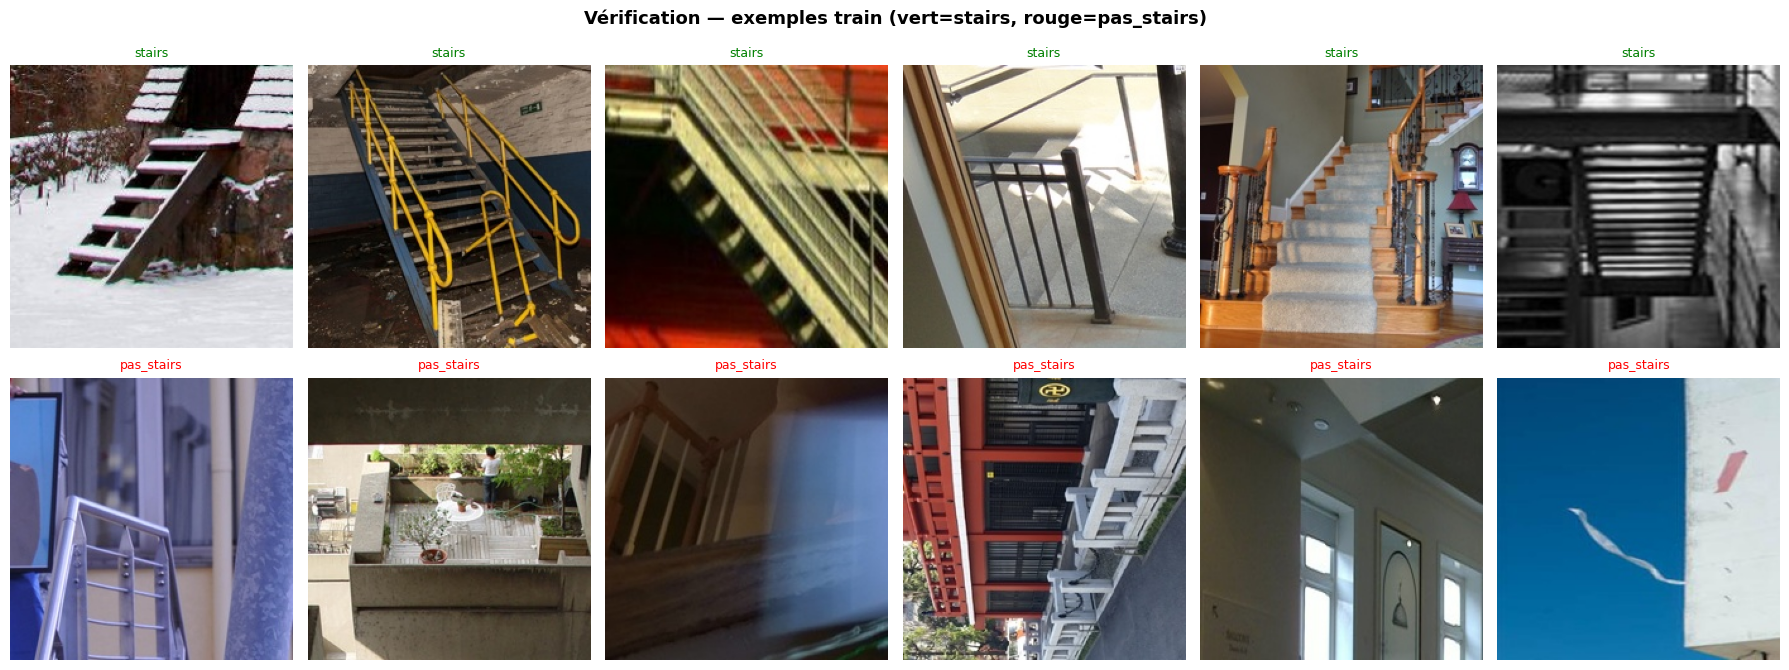

In [16]:
# Afficher quelques exemples de chaque classe
fig, axes = plt.subplots(2, 6, figsize=(18, 7))

# Ligne 1 — classe stairs
stairs_files = os.listdir(f"{DATASET_DIR}/train/stairs")[:6]
for i, fname in enumerate(stairs_files):
    img = Image.open(f"{DATASET_DIR}/train/stairs/{fname}")
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title('stairs', color='green', fontsize=9)

# Ligne 2 — classe pas_stairs
neg_files_list = os.listdir(f"{DATASET_DIR}/train/pas_stairs")[:6]
for i, fname in enumerate(neg_files_list):
    img = Image.open(f"{DATASET_DIR}/train/pas_stairs/{fname}")
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title('pas_stairs', color='red', fontsize=9)

plt.suptitle('Vérification — exemples train (vert=stairs, rouge=pas_stairs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Sauvegarde CSV final

In [17]:
rows = []
for split in ["train", "val"]:
    for cls in ["stairs", "pas_stairs"]:
        label  = 1 if cls == "stairs" else 0
        folder = f"{DATASET_DIR}/{split}/{cls}"
        for fname in os.listdir(folder):
            if fname.endswith('.jpg'):
                rows.append({
                    "chemin": os.path.join(folder, fname),
                    "classe": cls,
                    "label":  label,
                    "split":  split
                })

df_final = pd.DataFrame(rows)
df_final.to_csv("/kaggle/working/stairs_dataset.csv", index=False)

print(f"✅ {len(df_final)} images sauvegardées")
print(df_final.groupby(["split","classe"]).size().reset_index(name="count"))

✅ 9541 images sauvegardées
   split      classe  count
0  train  pas_stairs   3086
1  train      stairs   4546
2    val  pas_stairs    768
3    val      stairs   1141
